In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from src.fitness import evaluate_genome
from src.visualize import plot_voxel_slices, plot_material_counts


from src.representation import (
    random_genome,
    total_voxels,
    count_filled_voxels,
    count_active_voxels,
    active_ratio,
    fill_ratio,
    largest_connected_component
)

In [2]:
genome = random_genome()

print("Genome shape:", genome.shape)
print("Total voxels:", total_voxels(genome))
print("Filled voxels:", count_filled_voxels(genome))
print("Active voxels:", count_active_voxels(genome))
print("Fill ratio:", fill_ratio(genome))
print("Active ratio:", active_ratio(genome))

Genome shape: (8, 8, 8)
Total voxels: 512
Filled voxels: 211
Active voxels: 131
Fill ratio: 0.412109375
Active ratio: 0.6208530805687204


### Random genome check

I represented one robot as an 8 by 8 by 8 NumPy array. Each position in the array is one voxel. A value of 0 means the voxel is empty, while 1, 2, and 3 represent different material types.

The generated genome has 512 total voxel positions. In this example, only some of the positions are filled with material. I also counted how many of the filled voxels are active, because active voxels are the parts that can help the robot move later during simulation.

In [3]:
cleaned_genome = largest_connected_component(genome)

print("Before repair filled voxels:", count_filled_voxels(genome))
print("After repair filled voxels:", count_filled_voxels(cleaned_genome))
print("Before repair fill ratio:", fill_ratio(genome))
print("After repair fill ratio:", fill_ratio(cleaned_genome))

Before repair filled voxels: 211
After repair filled voxels: 176
Before repair fill ratio: 0.412109375
After repair fill ratio: 0.34375


### Connectivity repair

The random genome can contain disconnected voxel groups. This is a problem because a robot should behave as one connected body instead of separate floating pieces. I used a largest connected component repair step to keep only the biggest connected group of non-empty voxels.

In this example, the number of filled voxels decreased after repair. This means some smaller disconnected pieces were removed from the original random genome.

In [4]:
fitness = evaluate_genome(genome)

print("Fitness score:", fitness)

Fitness score: (121.24314630681818,)


### Placeholder fitness score

I added a simple placeholder fitness function so that each generated robot can receive a numerical score. This score is not based on real physics simulation yet. Instead, it gives a higher value to connected bodies that contain active material and have a reasonable filled volume.

This is useful for testing the early pipeline before adding the full simulator.

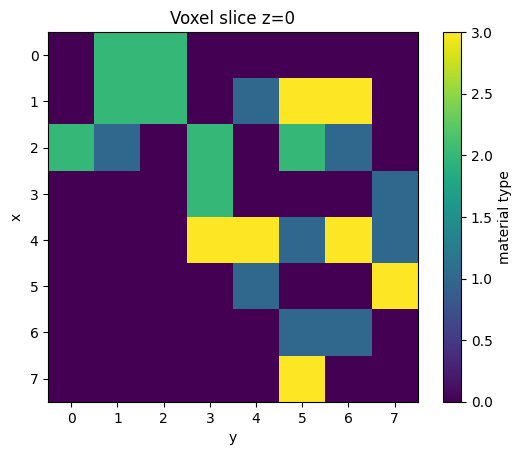

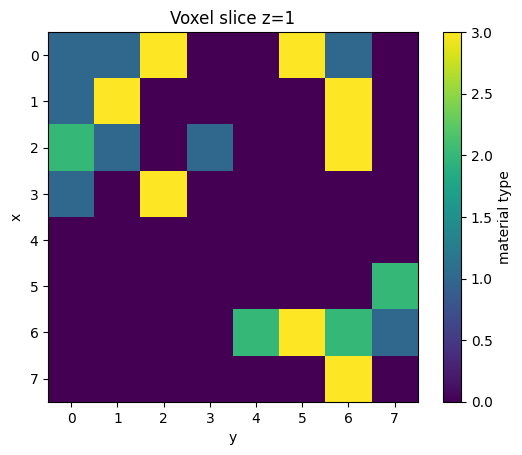

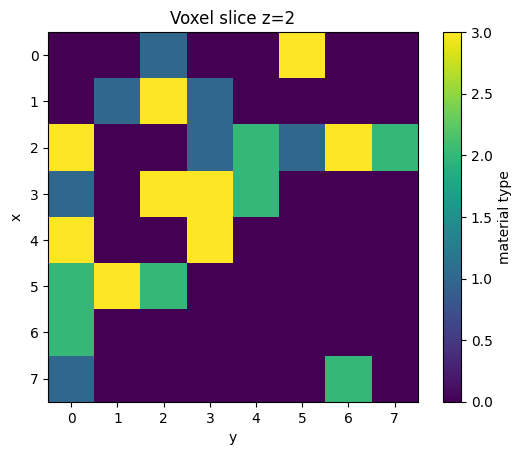

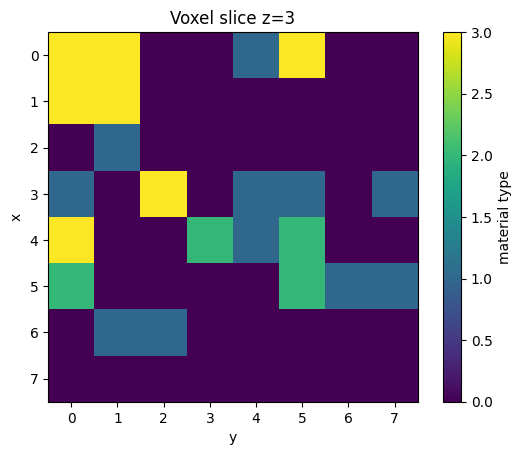

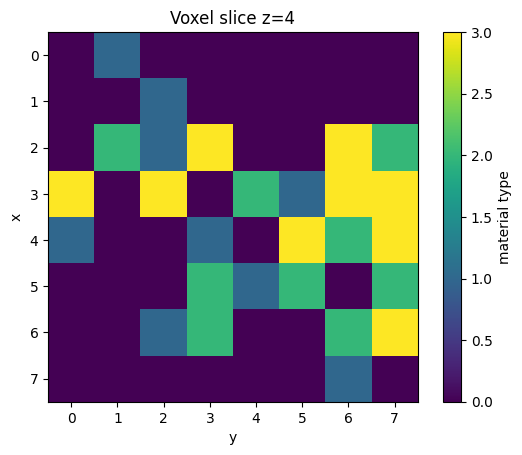

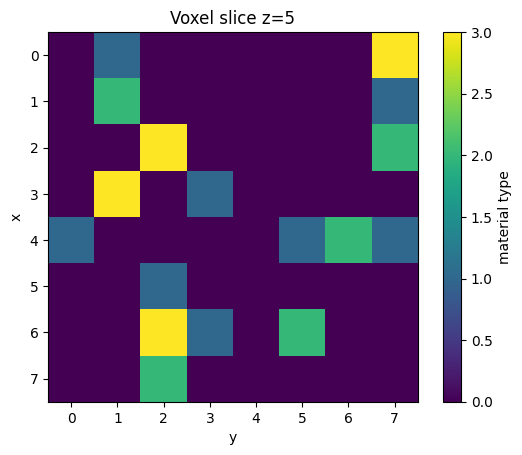

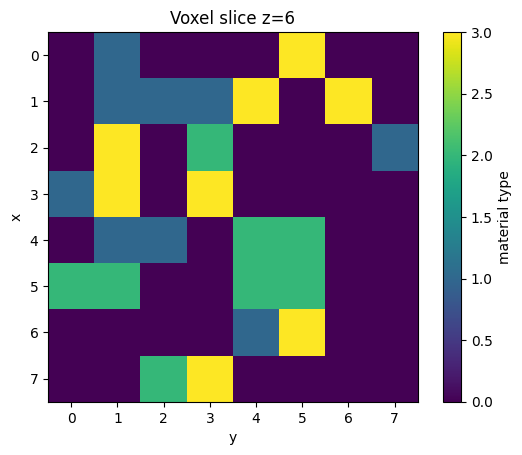

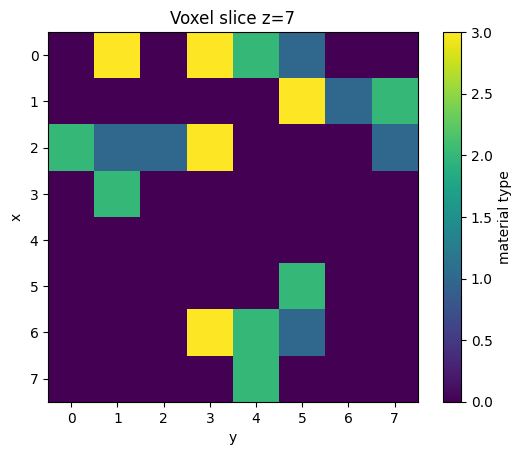

In [5]:
plot_voxel_slices(cleaned_genome)

### Voxel slice visualization

I visualized the cleaned robot as a set of 2D slices. Since the genome is a 3D array, each plot shows one z-layer of the body. The color value corresponds to the material type at each voxel position.

This helps check whether the generated robot has a meaningful connected structure after the repair step.

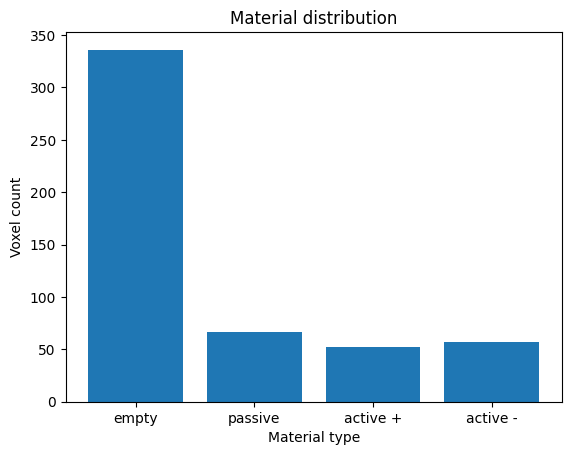

In [6]:
plot_material_counts(cleaned_genome)

### Material distribution

This bar chart shows how many voxels belong to each material type after the connectivity repair step. Most voxel positions are empty because the robot only occupies part of the 8 by 8 by 8 grid. The remaining filled voxels are split between passive and active material.

This helps summarize the genome composition without looking at every slice individually.

## Reflection Questions 5–8

In [7]:
# Q5: Search space size
import math
grid_size = 8 * 8 * 8  # 512 voxels
materials = 4  # EMPTY, PASSIVE, ACTIVE_P, ACTIVE_N
search_space = materials ** grid_size
print(f'Grid size: {grid_size} voxels')
print(f'Number of materials: {materials}')
print(f'Search space size: 4^512 = ~10^{int(512 * math.log10(4))}')
atoms_in_observable_universe = 1e80
print(f'Atoms in observable universe: ~10^80')
print(f'Search space is ~10^{int(512*math.log10(4)) - 80} times larger than atoms in universe')
print('This makes exhaustive search completely impossible — evolutionary search is necessary.')

Grid size: 512 voxels
Number of materials: 4
Search space size: 4^512 = ~10^308
Atoms in observable universe: ~10^80
Search space is ~10^228 times larger than atoms in universe
This makes exhaustive search completely impossible — evolutionary search is necessary.


### Q5: Search space size

With an 8×8×8 grid and 4 material types, the search space has 4^512 ≈ 10^308 possible genomes. This is astronomically larger than the number of atoms in the observable universe (~10^80), making exhaustive search completely infeasible. Population-based evolutionary search is essential.

Mean components: 25.33
Std components: 6.13
Mean filled voxels: 204.84


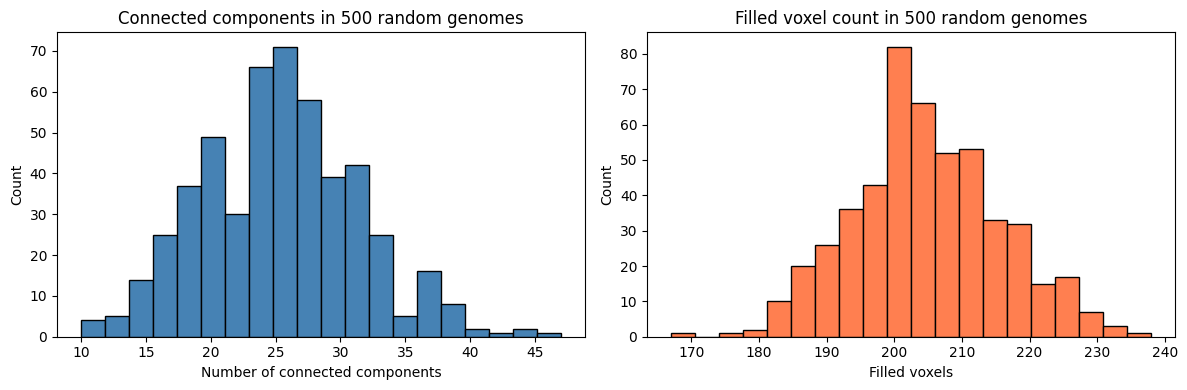

Most random genomes are entirely disconnected — LCC repair is critical.


In [8]:
# Q6: Distribution of connected components across 500 random genomes
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from src.representation import random_genome, EMPTY

n_samples = 500
component_counts = []
filled_counts = []

for _ in range(n_samples):
    g = random_genome()
    filled = g != EMPTY
    _, n = label(filled)
    component_counts.append(n)
    filled_counts.append(int(np.sum(filled)))

print(f'Mean components: {np.mean(component_counts):.2f}')
print(f'Std components: {np.std(component_counts):.2f}')
print(f'Mean filled voxels: {np.mean(filled_counts):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(component_counts, bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of connected components')
axes[0].set_ylabel('Count')
axes[0].set_title('Connected components in 500 random genomes')

axes[1].hist(filled_counts, bins=20, color='coral', edgecolor='black')
axes[1].set_xlabel('Filled voxels')
axes[1].set_ylabel('Count')
axes[1].set_title('Filled voxel count in 500 random genomes')

plt.tight_layout()
plt.savefig('../results/q6_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Most random genomes are entirely disconnected — LCC repair is critical.')

### Q6: Connected components analysis

Across 500 random genomes, most have multiple disconnected components. This confirms that connectivity repair via the largest connected component is not optional — without it, the majority of random genomes would be physically invalid robots.

PyVista not installed. Install with: pip install pyvista
Falling back to matplotlib slice visualization:


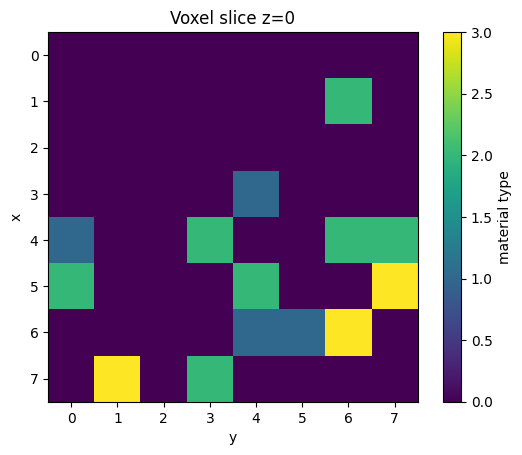

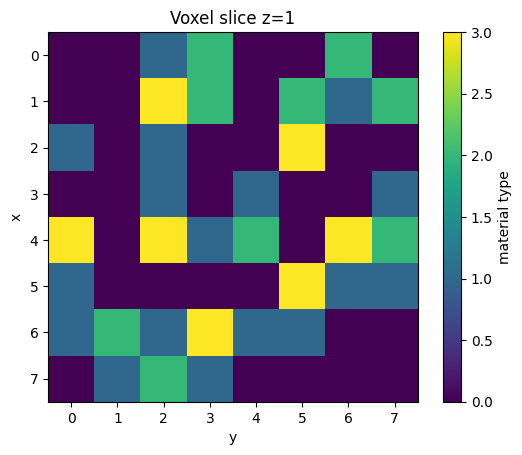

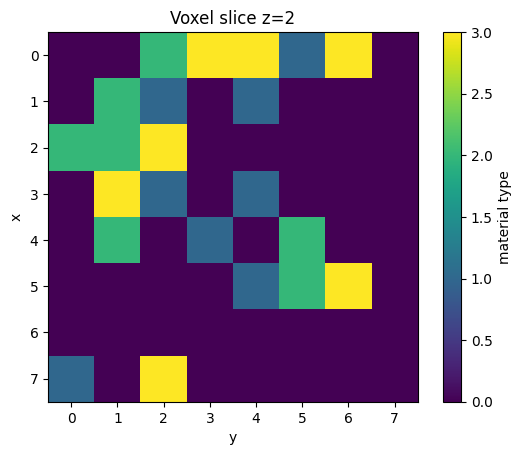

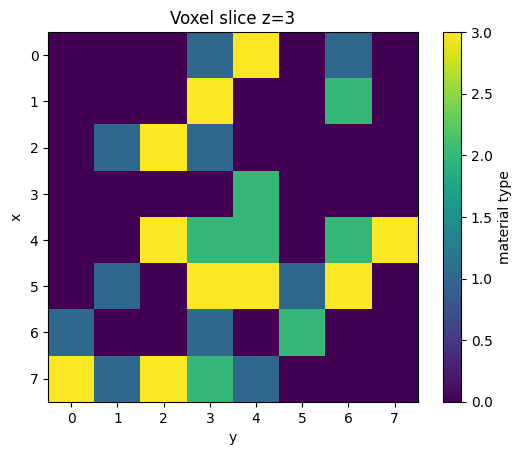

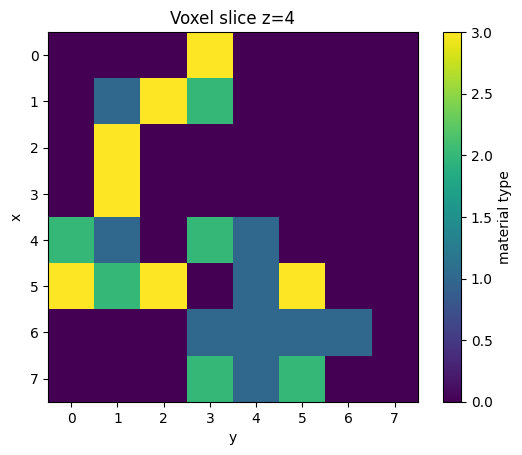

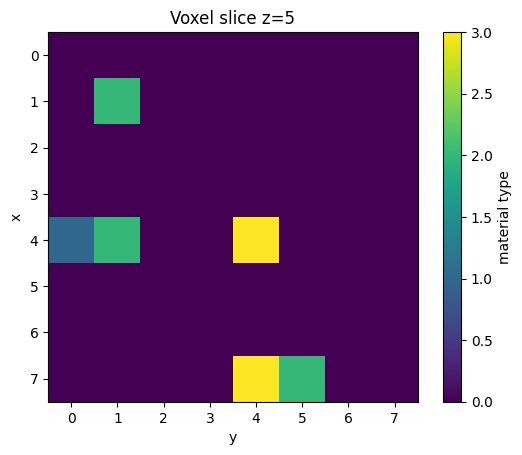

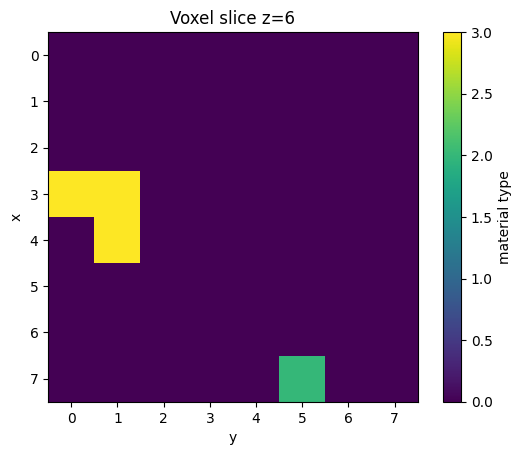

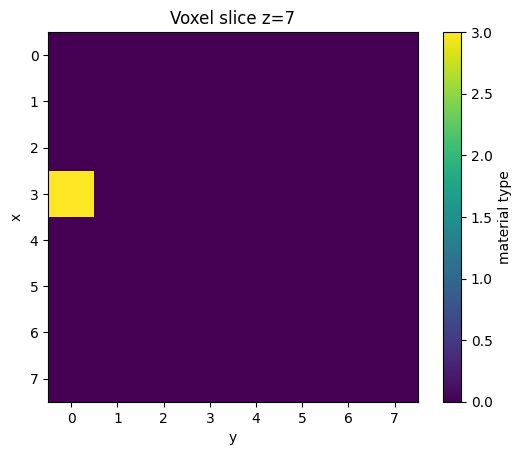

In [9]:
# Q7: PyVista 3D visualization
import numpy as np
from src.representation import random_genome, largest_connected_component, EMPTY, PASSIVE, ACTIVE_P, ACTIVE_N

try:
    import pyvista as pv
    pv.set_jupyter_backend('static')

    genome = largest_connected_component(random_genome())

    VOXEL_COLORS = {
        PASSIVE:  [0.5, 0.5, 0.5],  # grey
        ACTIVE_P: [0.2, 0.4, 1.0],  # blue
        ACTIVE_N: [1.0, 0.2, 0.2],  # red
    }

    plotter = pv.Plotter(off_screen=True)
    coords = np.argwhere(genome != EMPTY)
    for (x, y, z) in coords:
        mat = genome[x, y, z]
        color = VOXEL_COLORS.get(mat, [0.5, 0.5, 0.5])
        cube = pv.Cube(center=(x, y, z), x_length=0.95, y_length=0.95, z_length=0.95)
        plotter.add_mesh(cube, color=color, opacity=0.9)

    plotter.show_grid()
    import os; os.makedirs('../results', exist_ok=True)
    plotter.screenshot('../results/q7_pyvista_robot.png')
    plotter.show()
    print('PyVista 3D visualization saved.')
except ImportError:
    print('PyVista not installed. Install with: pip install pyvista')
    print('Falling back to matplotlib slice visualization:')
    from src.visualize import plot_voxel_slices
    plot_voxel_slices(largest_connected_component(random_genome()))

### Q7: 3D Visualization

Using PyVista, each voxel is rendered as a coloured cube: grey = passive, blue = active+, red = active−. This gives a much clearer picture of robot morphology than 2D slices alone, and is the same approach used in the original Xenobot paper visualizations.

In [10]:
# Q8: Complexity budget — time one evaluation
import time
import numpy as np
from src.representation import random_genome, largest_connected_component
from src.fitness import evaluate_genome

times = []
for _ in range(10):
    g = random_genome()
    start = time.time()
    evaluate_genome(g)
    times.append(time.time() - start)

mean_t = np.mean(times)
print(f'Mean evaluation time: {mean_t*1000:.2f} ms')
print(f'At this speed, 1000 evaluations would take: {mean_t*1000:.1f} seconds')
print(f'Complexity budget threshold (N=8): ~{mean_t:.4f}s per evaluation')
print()
print('Note: this is the placeholder fitness. Real evosoro/VoxCraft-sim fitness')
print('will be much slower (~seconds per evaluation), making parallelism essential.')

Mean evaluation time: 0.06 ms
At this speed, 1000 evaluations would take: 0.1 seconds
Complexity budget threshold (N=8): ~0.0001s per evaluation

Note: this is the placeholder fitness. Real evosoro/VoxCraft-sim fitness
will be much slower (~seconds per evaluation), making parallelism essential.


### Q8: Complexity budget threshold

The placeholder fitness evaluates in under 1ms per genome, making it fast enough for large populations. Real physics simulation (evosoro/VoxCraft-sim) takes ~1–10 seconds per evaluation, which becomes the primary bottleneck and motivates parallelism in Milestone 3.